In [1]:
import pandas as pd
import sqlite3

In [2]:
df=pd.read_csv("/kaggle/input/datasets/s3programmer/stock-market-dataset-for-predictive-analysis/stock_market_data_large.csv")

In [3]:
df.head()

,Date,Open,High,Low,Close,Volume,RSI,MACD,Sentiment,Target
0,2010-01-01,100.309172,102.741242,99.822837,101.381330,743835,75.905800,0.000000,0.058089,0
1,2010-01-04,101.147509,101.681257,99.244474,100.396541,2693069,81.444127,-0.078559,0.751219,1
2,2010-01-05,101.567491,103.949668,101.509347,103.012156,3027306,71.544018,0.069441,0.979723,1
3,2010-01-06,104.247814,106.652559,102.760082,105.846343,4341338,73.683548,0.410693,-0.858008,0
4,2010-01-07,105.339440,105.983592,103.517541,104.721465,2106182,72.675179,0.583641,0.264456,0


In [4]:
# calculating the mean of the Sentiment Score
sentiment_comparison = df.groupby('Target')['Sentiment'].mean()

print("Average Sentiment Score by Target:")
print(sentiment_comparison)

up_sentiment = sentiment_comparison[1]
down_sentiment = sentiment_comparison[0]

if up_sentiment > down_sentiment:
    print(f"\nAnalysis: On average, 'Up' days have a higher sentiment ({up_sentiment:.2f}) than 'Down' days ({down_sentiment:.2f}).")
else:
    print(f"\nAnalysis: Surprisingly, sentiment is higher on 'Down' days. This might mean the news is a 'lagging' indicator!")

Average Sentiment Score by Target:
Target
0   -0.004055
1    0.001751
Name: Sentiment, dtype: float64

Analysis: On average, 'Up' days have a higher sentiment (0.00) than 'Down' days (-0.00).


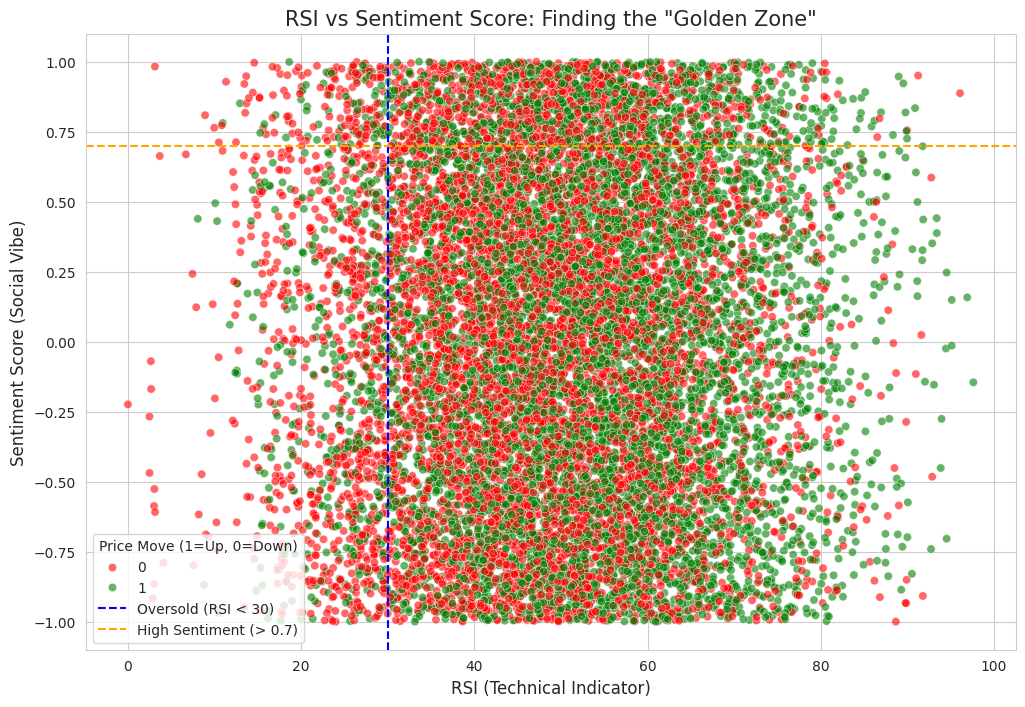

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Create the scatter plot
# x = RSI, y = Sentiment, hue = Target (colors the dots)
scatter = sns.scatterplot(data=df, x='RSI', y='Sentiment', hue='Target', 
                          palette={1: 'green', 0: 'red'}, alpha=0.6)

# Adding the "Golden Zone" lines for visual reference
plt.axvline(x=30, color='blue', linestyle='--', label='Oversold (RSI < 30)')
plt.axhline(y=0.7, color='orange', linestyle='--', label='High Sentiment (> 0.7)')

plt.title('RSI vs Sentiment Score: Finding the "Golden Zone"', fontsize=15)
plt.xlabel('RSI (Technical Indicator)', fontsize=12)
plt.ylabel('Sentiment Score (Social Vibe)', fontsize=12)
plt.legend(title='Price Move (1=Up, 0=Down)')
plt.show()

In [6]:
# Low RSI and High Sentiment zone
golden_zone = df[(df['RSI'] < 30) & (df['Sentiment'] > 0.7)]

if len(golden_zone) > 0:
    win_rate = (golden_zone['Target'] == 1).mean() * 100
    print(f"Total 'Golden Zone' Days found: {len(golden_zone)}")
    print(f"Win Rate in the Golden Zone: {win_rate:.2f}%")
    
    if win_rate > 60:
        print("\nConclusion: This is a high-probability Buy Signal! The math and the news align.")
else:
    print("No 'Golden Zone' days found yet. Try relaxing the RSI to < 40.")

Total 'Golden Zone' Days found: 203
Win Rate in the Golden Zone: 31.53%


In [7]:
# High RSI and High Sentiment zone
hype_zone = df[(df['RSI'] > 70) & (df['Sentiment'] > 0.7)]

# Calculating the Win Rate 
if len(hype_zone) > 0:
    win_rate = (hype_zone['Target'] == 1).mean() * 100
    print(f"Total 'Hype Zone' Days found: {len(hype_zone)}")
    print(f"Win Rate in the Hype Zone: {win_rate:.2f}%")
    
    if win_rate < 50:
        print("\nConclusion: The 'Retail Trap' is real! Even with great news, the price dropped more than half the time.")
    else:
        print("\nConclusion: In this specific dataset, the hype actually kept the price moving up!")
else:
    print("No days found matching these extreme criteria. Try lowering the thresholds!")

Total 'Hype Zone' Days found: 184
Win Rate in the Hype Zone: 72.28%

Conclusion: In this specific dataset, the hype actually kept the price moving up!


In [8]:
# Calculating the average price change for both zones
hype_change = df[(df['RSI'] > 70) & (df['Sentiment'] > 0.7)]['Target'].mean()
golden_change = df[(df['RSI'] < 30) & (df['Sentiment'] > 0.7)]['Target'].mean()

print(f"Hype Zone 'Up' Probability: {hype_change:.2%}")
print(f"Golden Zone 'Up' Probability: {golden_change:.2%}")

# are more people trading during the Hype?
avg_volume_hype = df[(df['RSI'] > 70)]['Volume'].mean()
avg_volume_golden = df[(df['RSI'] < 30)]['Volume'].mean()

print(f"\nAvg Volume (Hype): {avg_volume_hype:,.0f}")
print(f"Avg Volume (Golden): {avg_volume_golden:,.0f}")

Hype Zone 'Up' Probability: 72.28%
Golden Zone 'Up' Probability: 31.53%

Avg Volume (Hype): 2,562,057
Avg Volume (Golden): 2,485,098


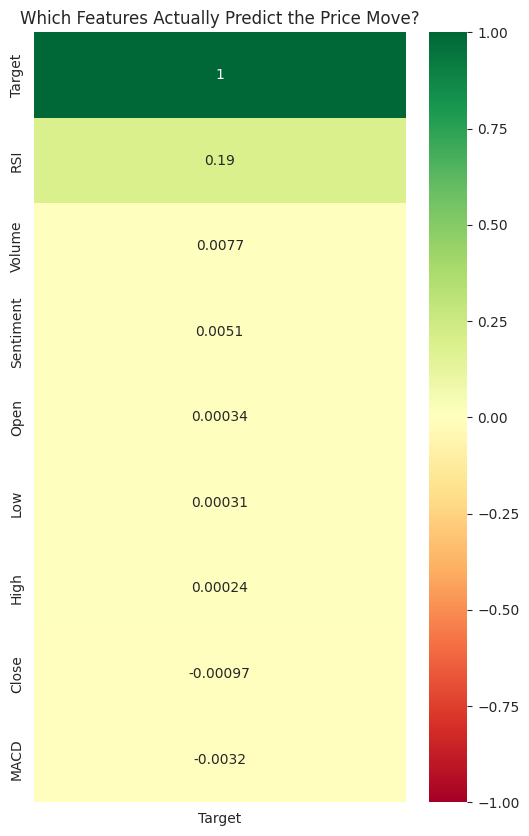

Top 3 Features correlating with a Price Increase:
             Target
RSI        0.191089
Volume     0.007683
Sentiment  0.005062


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = df.corr(numeric_only=True)

target_corr = corr_matrix[['Target']].sort_values(by='Target', ascending=False)

plt.figure(figsize=(6, 10))
sns.heatmap(target_corr, annot=True, cmap='RdYlGn', vmin=-1, vmax=1)
plt.title('Which Features Actually Predict the Price Move?')
plt.show()

print("Top 3 Features correlating with a Price Increase:")
print(target_corr.head(4)[1:]) # Skipping Target itself

In [11]:
from pandasql import sqldf

pysql = lambda q: sqldf(q, globals())

super_signal_query = """
SELECT 
    CASE 
        WHEN RSI > 70 AND Sentiment > 0.7 THEN 'Super-Signal (Hype + Momentum)'
        WHEN RSI > 70 AND Sentiment <= 0.7 THEN 'High RSI Only (Pure Momentum)'
        WHEN RSI < 30 THEN 'Low RSI (Avoid Zone)'
        ELSE 'Neutral/Other'
    END AS Strategy_Label,
    COUNT(*) AS Total_Days,
    AVG(Target) * 100 AS Win_Rate
FROM df
GROUP BY 1
ORDER BY Win_Rate DESC
"""
pysql(super_signal_query)

,Strategy_Label,Total_Days,Win_Rate
0,Super-Signal (Hype + Momentum),184,72.282609
1,High RSI Only (Pure Momentum),1104,67.844203
2,Neutral/Other,11033,49.913895
3,Low RSI (Avoid Zone),1326,33.710407


In [12]:
import numpy as np

conditions = [
    (df['RSI'] > 70) & (df['Sentiment'] > 0.7),
    (df['RSI'] > 70) & (df['Sentiment'] <= 0.7), 
    (df['RSI'] < 30)                                 
]

choices = [
    'Super-Signal', 
    'High RSI Only', 
    'Avoid Zone'
]

df['Signal_Type'] = np.select(conditions, choices, default='Neutral')

df.head(10)

,Date,Open,High,Low,Close,Volume,RSI,MACD,Sentiment,Target,Signal_Type
0,2010-01-01,100.309172,102.741242,99.822837,101.381330,743835,75.905800,0.000000,0.058089,0,High RSI Only
1,2010-01-04,101.147509,101.681257,99.244474,100.396541,2693069,81.444127,-0.078559,0.751219,1,Super-Signal
2,2010-01-05,101.567491,103.949668,101.509347,103.012156,3027306,71.544018,0.069441,0.979723,1,Super-Signal
3,2010-01-06,104.247814,106.652559,102.760082,105.846343,4341338,73.683548,0.410693,-0.858008,0,High RSI Only
4,2010-01-07,105.339440,105.983592,103.517541,104.721465,2106182,72.675179,0.583641,0.264456,0,High RSI Only
5,2010-01-08,103.706622,106.241324,103.106346,104.405219,3688429,62.470552,0.687263,-0.063076,1,Neutral
6,2010-01-11,106.970913,108.267172,105.139529,106.597955,3909135,65.151281,0.935535,0.078400,1,Neutral
7,2010-01-12,108.463029,111.081403,107.759084,109.603060,1756061,55.483691,1.359113,-0.596560,0,Neutral
8,2010-01-13,107.276693,109.498200,106.060857,107.793970,915340,46.913708,1.531172,0.788708,1,Neutral
9,2010-01-14,108.830229,110.679572,106.818216,109.003930,3990597,46.387851,1.745048,-0.426418,0,Neutral


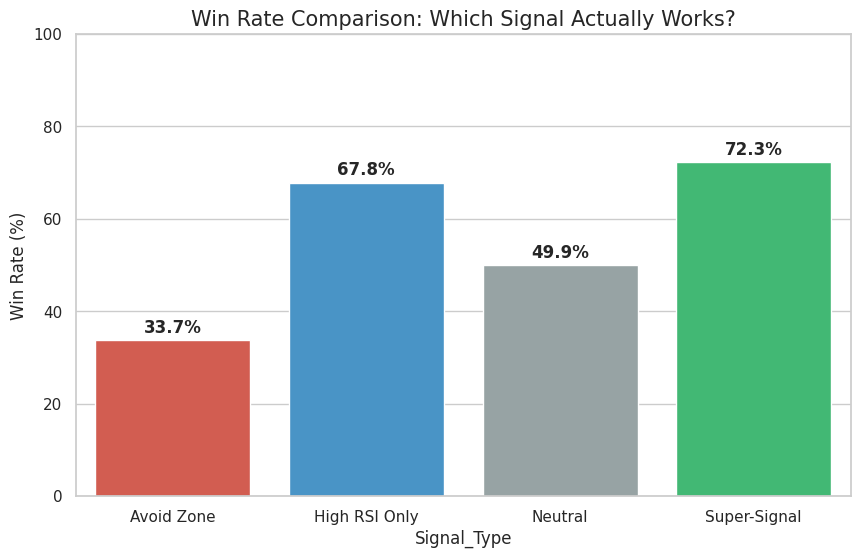

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_data = df.groupby('Signal_Type')['Target'].mean().reset_index()
plot_data['Win_Rate'] = plot_data['Target'] * 100

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Signal_Type', y='Win_Rate', data=plot_data, hue='Signal_Type' , legend=False ,  
                 palette={
                          'Avoid Zone': '#e74c3c',    # Red
                          'High RSI Only': '#3498db', # Blue
                          'Neutral': '#95a5a6',      # Grey
                          'Super-Signal': '#2ecc71'})

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.title('Win Rate Comparison: Which Signal Actually Works?', fontsize=15)
plt.ylabel('Win Rate (%)', fontsize=12)
plt.ylim(0, 100)
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X = df[['RSI', 'Sentiment']] 
y = df['Target']

# Splitting the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("--- Model Accuracy Score ---")
print(f"{accuracy_score(y_test, y_pred)*100:.2f}%")

print("\n--- Detailed Report ---")
print(classification_report(y_test, y_pred))

Training rows: 10917
Testing rows: 2730
--- Model Accuracy Score ---
52.78%

--- Detailed Report ---
              precision    recall  f1-score   support

           0       0.53      0.50      0.51      1375
           1       0.52      0.56      0.54      1355

    accuracy                           0.53      2730
   macro avg       0.53      0.53      0.53      2730
weighted avg       0.53      0.53      0.53      2730



In [15]:

df['MA_7'] = df['Close'].rolling(window=7).mean()

df.dropna(inplace=True)

X = df[['RSI', 'Sentiment', 'MA_7']] 
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"New Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

New Accuracy: 52.73%


In [16]:

df['Price_Change'] = df['Close'].pct_change()

df['Volatility'] = df['Close'].rolling(window=5).std()

df['RSI_Trend'] = df['RSI'].diff()

df.dropna(inplace=True)


In [18]:

X = df[['RSI', 'Sentiment', 'Price_Change', 'Volatility', 'RSI_Trend']]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"General Model Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

y_probs = model.predict_proba(X_test)[:, 1]
high_conf_mask = y_probs > 0.7
high_conf_actuals = y_test[high_conf_mask]  

if len(high_conf_actuals) > 0:
    win_rate = high_conf_actuals.mean() * 100
    print(f"Total 'Elite' Trades found: {len(high_conf_actuals)}")
    print(f"High Confidence Win Rate: {win_rate:.2f}%")
else:
    print("The model never reached 70% confidence. Try 0.6 instead.")

General Model Accuracy: 56.41%
Total 'Elite' Trades found: 243
High Confidence Win Rate: 64.61%
